In [17]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [30]:
#Load Dataset
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 8:26,3.39,17850.0,United Kingdom


In [19]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [20]:
#Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [21]:
#Statistical Summary
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [22]:
#create sales Column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [23]:
#top products
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

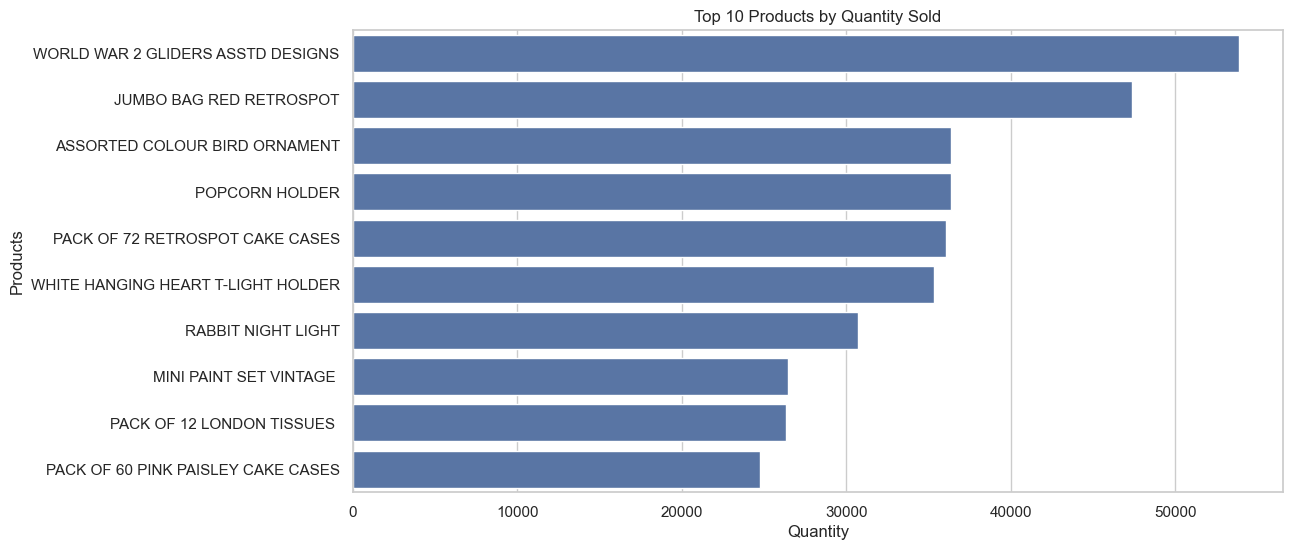

In [24]:
#plot top products
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Products")

plt.show()

In [25]:
#Country waise sales
country_sales = (
    df.groupby("Country")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)
country_sales

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Sales, dtype: float64

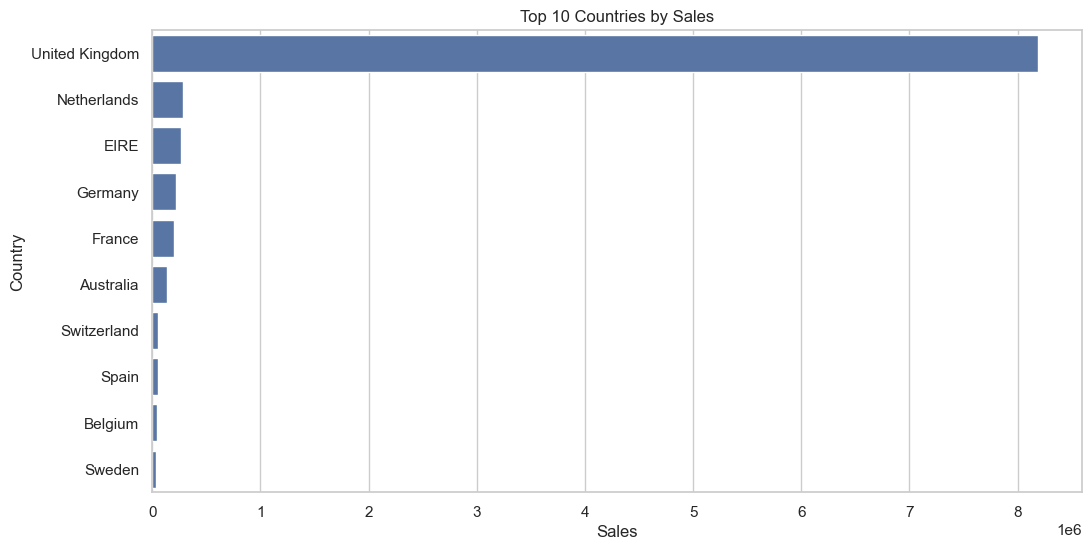

In [26]:
#plot country sales
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)
plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.show()

In [27]:
#monthly sales
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

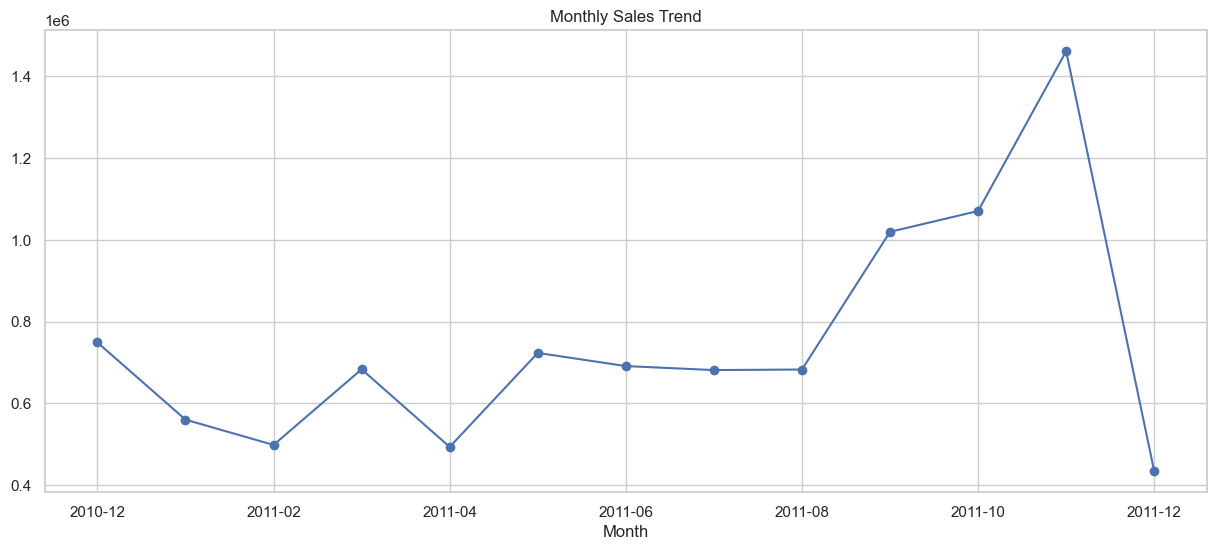

In [28]:
#monthly sales graph
plt.figure(figsize=(15,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.grid(True)

plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

# Create Sales Column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

# Convert Invoice Date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [3]:
#total rows and columns
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 541909
Columns : 9


In [4]:
#missing Values
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Sales               0
dtype: int64


In [5]:
#unique customers
print("Unique Customers :", df["CustomerID"].nunique())

Unique Customers : 4372


In [6]:
#unique products
print("Unique Products :", df["Description"].nunique())

Unique Products : 4223


In [7]:
#distinct countries
print("Distinct Countries :", df["Country"].nunique())

Distinct Countries : 38


In [9]:
#earliest and latest invoice dates
print("Earliest Invoice Date :", df["InvoiceDate"].min())
print("Latest Invoice Date :", df["InvoiceDate"].max())

Earliest Invoice Date : 2010-12-01 08:26:00
Latest Invoice Date : 2011-12-09 12:50:00


In [10]:
#data cleaning

#cancelled orders
cancelled = df["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancelled Orders :", cancelled)

Cancelled Orders : 9288


In [11]:
#negative quantity/price
negative_quantity = (df["Quantity"] < 0).sum()
negative_price = (df["UnitPrice"] < 0).sum()

print("Negative Quantity :", negative_quantity)
print("Negative Price :", negative_price)

Negative Quantity : 10624
Negative Price : 2


In [12]:
#Missing customer IDs
print("Missing Customer IDs :", df["CustomerID"].isnull().sum())
#replace missing IDs
df["CustomerID"] = df["CustomerID"].fillna("Guest")


Missing Customer IDs : 135080


In [13]:
#duplicate rows
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 5268


In [14]:
#Business analysis

#Total revenue
total_revenue = df["Sales"].sum() 
print("Total Revenue :", total_revenue)

Total Revenue : 9747747.934


In [15]:
# highest revenue product
product = (
    df.groupby("Description")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(product.head(1))

Description
DOTCOM POSTAGE    206245.48
Name: Sales, dtype: float64


In [ ]:
#highest quantity sold
quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
print(quantity.head(1))

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53847
Name: Quantity, dtype: int64


In [17]:
#Average order value
order_value = (
    df.groupby("InvoiceNo")["Sales"]
      .sum()
)

print("Average Order Value :", order_value.mean())


Average Order Value : 376.3609240926641


In [18]:
#highest revenue country after UK
country_revenue = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
print("Highest Revenue Country after UK :", country_revenue.head(1))

Highest Revenue Country after UK : Country
Netherlands    284661.54
Name: Sales, dtype: float64


In [20]:
#highest total sales month
df["Month"] = df["InvoiceDate"].dt.month_name()

month_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(month_sales.head())

Month
November     1461756.250
December     1182625.030
October      1070704.670
September    1019687.622
May           723333.510
Name: Sales, dtype: float64


In [21]:
#Most orders by weekdays
df["Weekday"] = df["InvoiceDate"].dt.day_name()

weekday = (
    df.groupby("Weekday")["InvoiceNo"]
      .count()
      .sort_values(ascending=False)
)

print(weekday)

Weekday
Thursday     103857
Tuesday      101808
Monday        95111
Wednesday     94565
Friday        82193
Sunday        64375
Name: InvoiceNo, dtype: int64


In [ ]:
#most purchases by hour
df["Hour"] = df["InvoiceDate"].dt.hour

hour = (
    df.groupby("Hour")["InvoiceNo"]
      .count()
)

print(hour.sort_values(ascending=False))

Hour
12    78709
15    77519
13    72259
14    67471
11    57674
16    54516
10    49037
9     34332
17    28509
8      8909
18     7974
19     3705
20      871
7       383
6        41
Name: InvoiceNo, dtype: int64


In [23]:
#Customer Analysis
#Top 10 customers
customers = (
    df.groupby("CustomerID")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)
print(customers)

CustomerID
Guest      1447682.12
14646.0     279489.02
18102.0     256438.49
17450.0     187482.17
14911.0     132572.62
12415.0     123725.45
14156.0     113384.14
17511.0      88125.38
16684.0      65892.08
13694.0      62653.10
Name: Sales, dtype: float64


In [25]:
#Average orders per customers
order= (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)
print("Average Orders:", order.mean())

Average Orders: 5.9227075234392865


In [26]:
#one time buyers
one_time_buyers = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .value_counts()
    .get(1, 0)
)
print("One Time Buyers :", one_time_buyers)

One Time Buyers : 1313


In [29]:
#Repeat customers %
repeated_customers = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .value_counts()
    .get(2, 0)
)
print("Repeated Customers :", repeated_customers)

Repeated Customers : 817


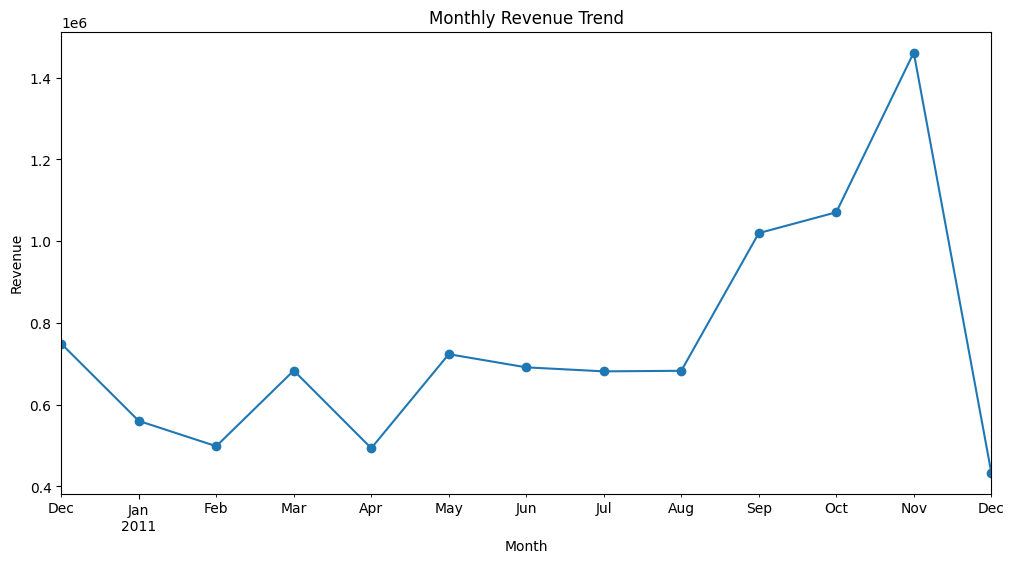

In [30]:
#adavanced analysis
#monthly revenue trend
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Sales"]
    .sum()
)
monthly_revenue.plot(marker="o", figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [33]:
#price vs quantity correlation
corr = np.corrcoef(df["UnitPrice"], df["Quantity"])[0, 1]
print("Price vs Quantity Correlation:", corr)

Price vs Quantity Correlation: -0.001234924544870288


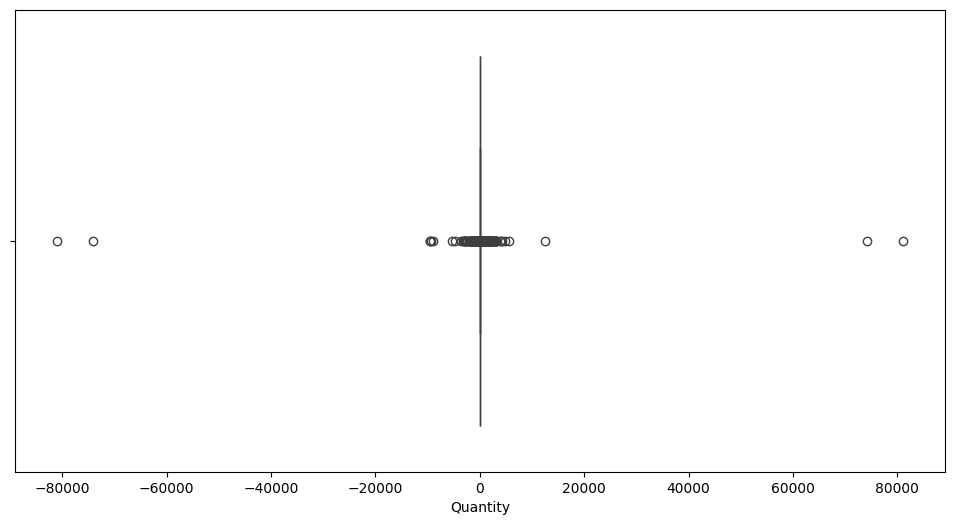

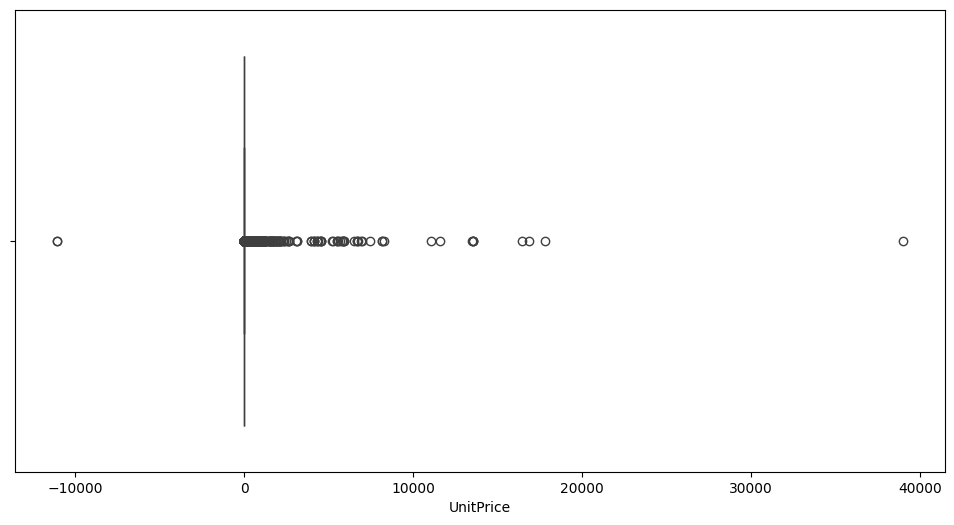

In [34]:
#outliers detection
plt.figure(figsize=(12,6))
sns.boxplot(x=df["Quantity"])
plt.show()
plt.figure(figsize=(12,6))
sns.boxplot(x=df["UnitPrice"])
plt.show()

In [35]:
#RFM Analysis
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot - x.max()).days,
    "InvoiceNo": "nunique",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          2      0.00
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
